## Péndulo elástico


1.   Número de particulas $N=1$
2.   Coordenadas $3N=3 (x,y,z)$
3.   Restricciones $k=1, z=0$(Restricción holonoma)
4.   Grados de libertad $M=3N-k=2$
5.   Coordenadas generalizadas$(q_1,q_2)=(θ,e)$
6.   Reglas de transformación:

$x=(L+e)\sin(θ)$

$x=-(L+e)\cos(θ)$

$z=0$




# Modelado de un Péndulo Elástico mediante Mecánica Lagrangiana

Este sistema consiste en una masa $m$ unida a un resorte de constante $k$ y longitud natural $L$, que oscila en un plano vertical bajo la influencia de la gravedad ($g$).

### 1. Variables del Sistema
1.   Número de particulas $N=1$
2.   Coordenadas $3N=3 (x,y,z)$
3.   Restricciones $k=1, z=0$(Restricción holonoma)
4.   Grados de libertad $M=3N-k=2$
5.   Coordenadas generalizadas$(q_1,q_2)=(θ,e)$
*   $q_1 = \theta$: Coordenada angular (ángulo respecto a la vertical).
*   $q_2 = e$: Elongación del resorte (distancia adicional a la longitud natural $L$).
*   $W = mg$: Peso de la masa.


### 2. Reglas de Transformación
Las coordenadas cartesianas y sus velocidades se definen como:

**Posición:**
$$x(q_1, q_2, t) = (L + q_2) \sin q_1$$
$$y(q_1, q_2, t) = -(L + q_2) \cos q_1$$
$$z(q_1, q_2, t) = 0$$

**Velocidad:**
$$\dot{x} = (L + q_2) \cos q_1 \dot{q}_1 + \dot{q}_2 \sin q_1$$
$$\dot{y} = (L + q_2) \sin q_1 \dot{q}_1 - \dot{q}_2 \cos q_1$$


### 3. Función de Energía Cinética ($T$)
La energía cinética total del sistema es $T = \frac{1}{2} m (\dot{x}^2 + \dot{y}^2)$:

$$T(q_1, q_2, \dot{q}_1, \dot{q}_2) = \frac{1}{2} m \left[ (L + q_2)^2 \dot{q}_1^2 + \dot{q}_2^2 \right]$$

#### Derivadas de la Energía Cinética:
| Respecto a $q_1$ | Respecto a $q_2$ |
| :--- | :--- |
| $\frac{\partial T}{\partial q_1} = 0$ | $\frac{\partial T}{\partial q_2} = m(L + q_2)\dot{q}_1^2$ |
| $\frac{\partial T}{\partial \dot{q}_1} = m(L + q_2)^2 \dot{q}_1$ | $\frac{\partial T}{\partial \dot{q}_2} = m\dot{q}_2$ |
| $\frac{d}{dt} \left( \frac{\partial T}{\partial \dot{q}_1} \right) = 2m(L + q_2)\dot{q}_1 \dot{q}_2 + m(L + q_2)^2 \ddot{q}_1$ | $\frac{d}{dt} \left( \frac{\partial T}{\partial \dot{q}_2} \right) = m\ddot{q}_2$ |


### 4. Fuerzas Generalizadas ($Q_i$)
Calculamos las fuerzas no conservativas o externas proyectadas en las coordenadas generalizadas. La fuerza neta es:
$$\vec{F} = -k q_2 \sin q_1 \hat{e}_x + (-W + k q_2 \cos q_1) \hat{e}_y$$

**Resultados:**
*   **Para $q_1$:** $Q_1 = \vec{F} \cdot \frac{\partial \vec{r}}{\partial q_1} = -W(L + q_2) \sin q_1$
*   **Para $q_2$:** $Q_2 = \vec{F} \cdot \frac{\partial \vec{r}}{\partial q_2} = W \cos q_1 - k q_2$


### 5. Ecuaciones de Lagrange
Aplicamos la forma general: $\frac{d}{dt} \left( \frac{\partial T}{\partial \dot{q}_k} \right) - \frac{\partial T}{\partial q_k} = Q_k$

1.  **Para $q_1$:**
    $$2m(L + q_2)\dot{q}_1 \dot{q}_2 + m(L + q_2)^2 \ddot{q}_1 = -W(L + q_2) \sin q_1$$
2.  **Para $q_2$:**
    $$m\ddot{q}_2 - m(L + q_2)\dot{q}_1^2 = W \cos q_1 - k q_2$$


### 6. Ecuaciones de Movimiento Finales
Despejando las aceleraciones generalizadas ($\ddot{q}_1$ y $\ddot{q}_2$):

> **Aceleración Angular:**
> $$\ddot{q}_1 = - \frac{2 \dot{q}_1 \dot{q}_2}{L + q_2} - \frac{g \sin q_1}{L + q_2}$$

> **Aceleración Radial (Elongación):**
> $$\ddot{q}_2 = g \cos q_1 - \left(\frac{k}{m}\right)q_2 + (L + q_2) \dot{q}_1^2$$



In [5]:
!pip install -Uq p celluloid


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from celluloid import Camera
from scipy.integrate import solve_ivp
deg=np.pi/180
rad=180/np.pi

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


AttributeError: 'NoneType' object has no attribute 'canvas'

Error in callback <function _draw_all_if_interactive at 0x7bf31ceb2de0> (for post_execute), with arguments args (),kwargs {}:


AttributeError: 'NoneType' object has no attribute 'canvas'

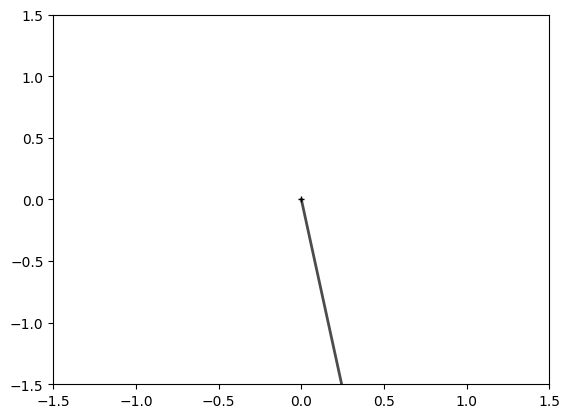

In [7]:
m=1.0  # mass of the pendulum 
L=1.0  # length of the pendulum 
k=0.5  # spring constant
g=9.81  # gravitational acceleration

def e_pendulum(t, y):
    q1, q2, dq1, dq2 = y
    ddq1 = - (2 * dq1 * dq2) / (L + q2) - (g * np.sin(q1)) / (L + q2)
    ddq2 = g * np.cos(q1) - (k / m) * q2 + (L + q2) * (dq1**2)
    return [dq1, dq2, ddq1, ddq2]

y0 = [np.pi/4, 0.2, 0, 0]  # initial conditions: [q1(0), q2(0), dq1(0), dq2(0)]
t_span = (0, 10)  # time span for the simulation
t_eval = np.linspace(t_span[0], t_span[1], 300)

sol = solve_ivp(e_pendulum, t_span, y0, t_eval=t_eval)

theta = sol.y[0]
q2= sol.y[1]
# Create the animation
fig, ax = plt.subplots()        
camera = Camera(fig)

for i in range(len(t_eval)):
    ax.clear()
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    x = (L + q2[i]) * np.sin(theta[i])
    y = -(L+q2[i]) * np.cos(theta[i])
    # Draw the pendulum
    ax.plot(0, 0, 'k+', markersize=5)  # pivot
    ax.plot([0, x], [0, y], 'k-', lw=2, alpha=0.7)  # rod
    ax.plot(x, y, 'ro', markersize=10)  # bob
    camera.snap()   
animation = camera.animate()
HTML(animation.to_jshtml())